In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

file_path = (r"C:\Users\amit6\OneDrive\Desktop\Intelligent-Retail-Customer-Analytics\Data\Processed_data\retail_feature_engineered.csv")

df = pd.read_csv(
    file_path,
    parse_dates=["InvoiceDate"]
)

df.head()

C:\Users\amit6\AppData\Local\Temp\ipykernel_6388\3135170241.py:10: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount,Year,Month,MonthName,Quarter,Day,DayName,Hour,IsWeekend,InvoiceTotal,BasketSize,PurchaseFrequency,AverageOrderValue,CustomerRevenue,ProductPurchaseCount,ProductRevenue,CustomerType
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom,83.40,2009,12,December,4,1,Tuesday,7,False,505.30,8,8.00,350.90,2433.28,522,21201.13,Regular
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,81.00,2009,12,December,4,1,Tuesday,7,False,505.30,8,8.00,350.90,2433.28,266,13787.93,Regular
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,81.00,2009,12,December,4,1,Tuesday,7,False,505.30,8,8.00,350.90,2433.28,350,18048.72,Regular
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom,100.80,2009,12,December,4,1,Tuesday,7,False,505.30,8,8.00,350.90,2433.28,560,18650.87,Regular
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom,30.00,2009,12,December,4,1,Tuesday,7,False,505.30,8,8.00,350.90,2433.28,2478,49300.57,Regular


In [2]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 1007913
Columns: 25


# Business Questions

- How large is the dataset?
- How many customers?
- How many invoices?
- How many products?
- How many countries?

In [3]:
overview = pd.DataFrame({
    "Metric":[
        "Transactions",
        "Invoices",
        "Customers",
        "Products",
        "Countries"
    ],
    "Value":[
        len(df),
        df["Invoice"].nunique(),
        df["Customer ID"].nunique(),
        df["StockCode"].nunique(),
        df["Country"].nunique()
    ]
})

overview

,Metric,Value
0,Transactions,1007913
1,Invoices,40079
2,Customers,5878
3,Products,4917
4,Countries,43


### Observation

The dataset contains transactions from multiple countries involving thousands of invoices, products, and customers. This confirms that the data is suitable for customer analytics, sales analysis, forecasting, and recommendation modeling.

In [4]:
total_revenue = df["TotalAmount"].sum()

total_orders = df["Invoice"].nunique()

total_customers = df["Customer ID"].nunique()

total_products = df["StockCode"].nunique()

avg_order_value = (
    df.groupby("Invoice")["TotalAmount"].sum().mean()
)

avg_basket_size = (
    df.groupby("Invoice")["StockCode"].count().mean()
)

kpi = pd.DataFrame({
    "Metric":[
        "Total Revenue",
        "Total Orders",
        "Total Customers",
        "Total Products",
        "Average Order Value",
        "Average Basket Size"
    ],
    "Value":[
        round(total_revenue,2),
        total_orders,
        total_customers,
        total_products,
        round(avg_order_value,2),
        round(avg_basket_size,2)
    ]
})

kpi

,Metric,Value
0,Total Revenue,20476260.45
1,Total Orders,40079.00
2,Total Customers,5878.00
3,Total Products,4917.00
4,Average Order Value,510.90
5,Average Basket Size,25.15


# Sales Analysis

1) What is the revenue distribution by transaction?

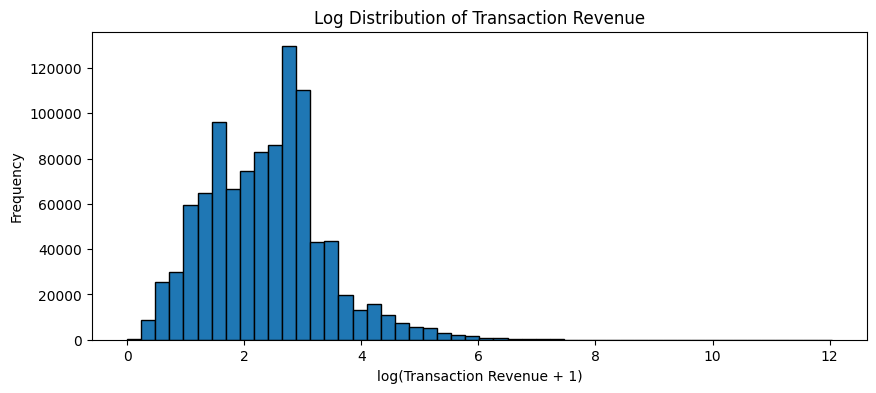

In [5]:
import numpy as np

plt.figure(figsize=(10,4))
plt.hist(np.log1p(df["TotalAmount"]), bins=50, edgecolor="black")

plt.title("Log Distribution of Transaction Revenue")
plt.xlabel("log(Transaction Revenue + 1)")
plt.ylabel("Frequency")
plt.show()

### Due to heavily skewed graph because of outliers , it is now represented with log values at x-axis . The overall transactions were in the range of 0-1000 but some of them were high around 1M thus outliers detected

In [6]:
df["TotalAmount"].describe()

count   1007913.00
mean         20.32
std         205.72
min           0.00
25%           4.13
50%          10.08
75%          17.70
max      168469.60
Name: TotalAmount, dtype: float64

2) Which invoices generate the highest revenue?

In [7]:
top_invoices = (
    df.groupby("Invoice")["TotalAmount"].sum().sort_values(ascending=False).head(10)
)

top_invoices

Invoice
581483   168469.60
541431    77183.60
574941    52940.94
576365    50653.91
533027    49844.99
531516    45332.97
493819    44051.60
556444    38970.00
524181    33167.80
567423    31698.16
Name: TotalAmount, dtype: float64

# Customer Analysis

1) Which customers contribute the most in the total revenue?

In [8]:
top_customers = (
    df.groupby('Customer ID')['TotalAmount'].sum().sort_values(ascending= False).head(10)
)
top_customers

Customer ID
18102.00   580987.04
14646.00   528602.52
14156.00   313437.62
14911.00   291420.81
17450.00   244784.25
13694.00   195640.69
17511.00   172132.87
16446.00   168472.50
16684.00   147142.77
12415.00   144458.37
Name: TotalAmount, dtype: float64

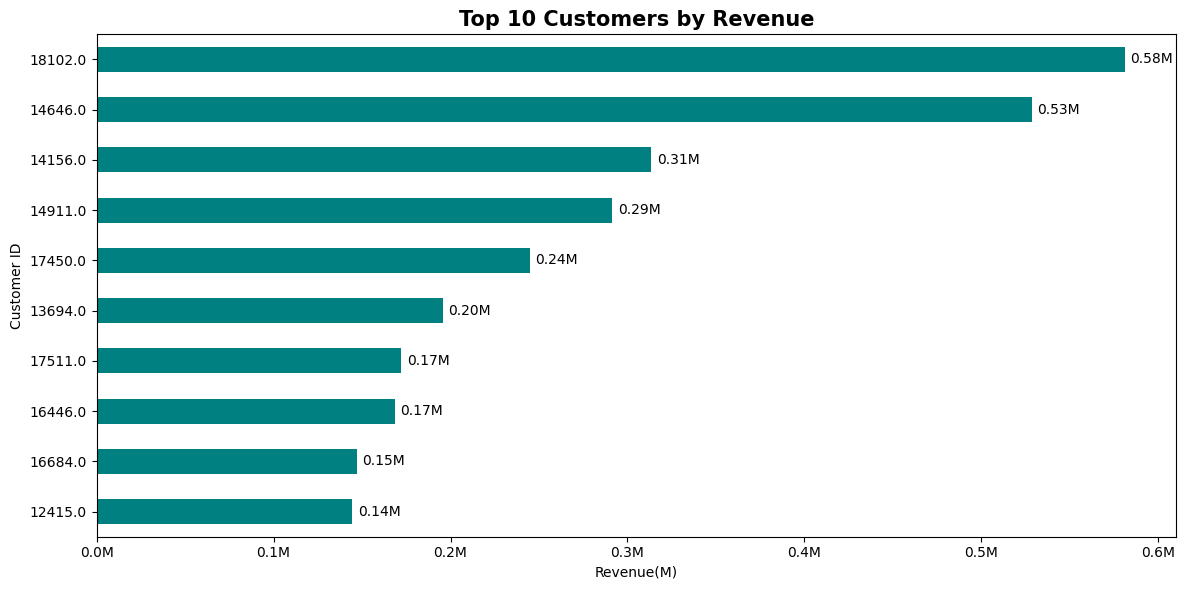

In [9]:
from matplotlib.ticker import FuncFormatter
fig, ax = plt.subplots(figsize=(12,6))

top_customers.sort_values().plot(kind="barh",color ='#008080')

plt.title("Top 10 Customers by Revenue",fontsize=15, weight='bold')
plt.xlabel("Revenue(M)")
plt.ylabel("Customer ID")


formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.2f}M')
plt.gca().xaxis.set_major_formatter(formatter)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))
for container in ax.containers:
    ax.bar_label(
        container,
        fmt=lambda x: f'{x/1e6:.2f}M', padding=4, fontsize=10
    )

plt.tight_layout()
plt.show()

Revenue is concentrated among a relatively small number of customers, indicating that retaining high-value customers can have a significant impact on overall sales.

2) How often do customers place orders?

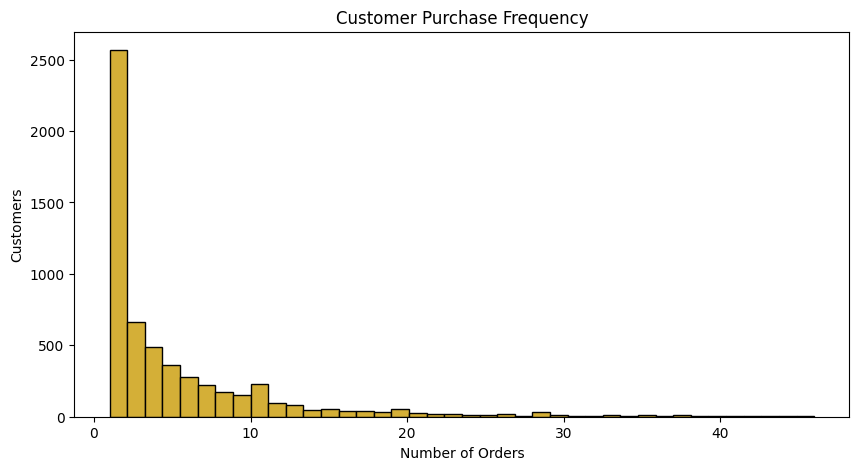

In [10]:
purchase_frequency = (
    df.groupby("Customer ID")["Invoice"]
      .nunique()
)
limit = purchase_frequency.quantile(0.99)
plt.figure(figsize=(10,5))

plt.hist( purchase_frequency[purchase_frequency <= limit], bins=40,color = '#D4AF37', edgecolor="black")

plt.title("Customer Purchase Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Customers")

plt.show()

This type of histogram is due to the outliers as most of the customers buy 1-3 products at a time and very few but also exist some who buy at a huge quantity. But this insight gives us an idea that customer retention is possible over the customers as large number of them buy low quantity products at a time.

3) How many customers purchase only once?

In [11]:
purchase_frequency = (
    df.groupby("Customer ID")["Invoice"]
      .nunique()
)

one_time = (purchase_frequency == 1).sum()
repeat = (purchase_frequency > 1).sum()

customer_type = pd.Series({
    "One-Time": one_time,
    "Repeat": repeat
})

customer_type

One-Time    1623
Repeat      4255
dtype: int64

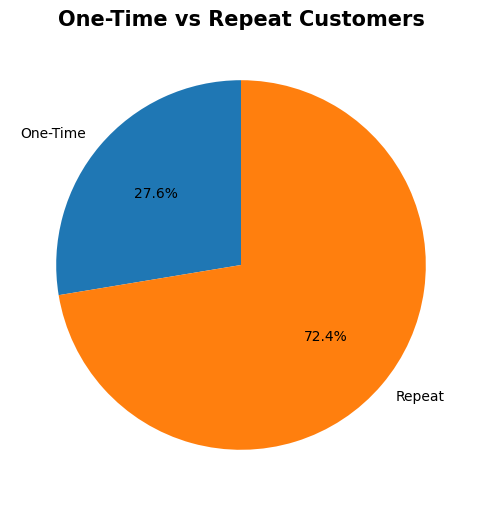

In [12]:
plt.figure(figsize=(6,6))

plt.pie(
    customer_type,
    labels=customer_type.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("One-Time vs Repeat Customers",fontsize=15, weight='bold')

plt.show()

4) Top Customers with most orders ?

In [13]:
top_frequency = (
    df.groupby("Customer ID")["Invoice"].nunique().sort_values(ascending=False).head(10)
)
top_frequency



Customer ID
14911.00    398
12748.00    336
17841.00    211
15311.00    208
13089.00    203
14606.00    192
14156.00    156
17850.00    155
14646.00    151
18102.00    145
Name: Invoice, dtype: int64

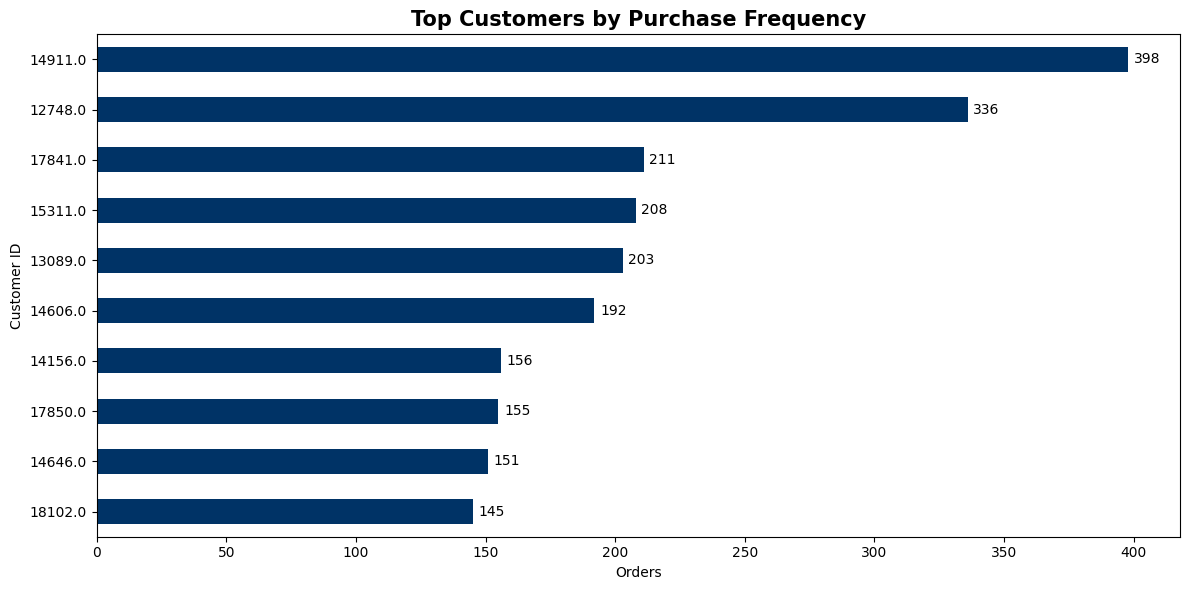

In [14]:
fig,ax = plt.subplots(figsize=(12,6))

top_frequency.sort_values().plot(kind="barh",color ='#003366')

plt.title("Top Customers by Purchase Frequency",fontsize=15, weight='bold')
plt.xlabel("Orders")
plt.ylabel("Customer ID")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",padding=4, fontsize=10, color="black"
    )
    
plt.tight_layout()
plt.show()

5) Which customers place the highest-value orders on average?

In [15]:
avg_order = (
    df.groupby("Customer ID")["InvoiceTotal"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

avg_order

Customer ID
16446.00   56158.47
15749.00   16883.72
15098.00   13305.50
12415.00   13108.89
13687.00   11880.84
12918.00   10953.50
13902.00   10929.23
18052.00   10877.18
12590.00    9211.58
12357.00    8972.21
Name: InvoiceTotal, dtype: float64

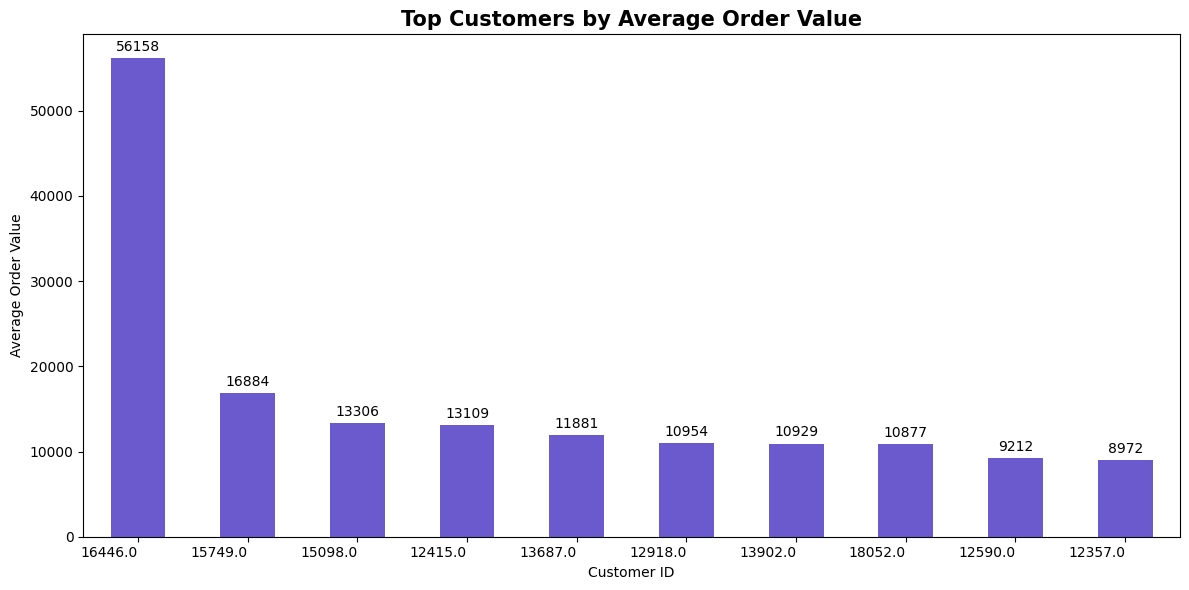

In [16]:
fig,ax = plt.subplots(figsize=(12,6))

avg_order.plot(kind="bar",color ='#6A5ACD')

plt.title("Top Customers by Average Order Value", fontsize=15, weight="bold")
plt.xlabel("Customer ID")
plt.ylabel("Average Order Value")

# Rotate Customer IDs for readability
plt.xticks(rotation=0, ha='right')

# Add labels on top of bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3,
        fontsize=10
    )
plt.tight_layout()
plt.show()

6) Do a small percentage of customers generate most of the revenue?

In [17]:
customer_sales = (
    df.groupby("Customer ID")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
)

pareto = customer_sales.reset_index()
pareto.columns = ["Customer ID", "Revenue"]

pareto["CumulativeRevenue"] = pareto["Revenue"].cumsum()
pareto["CumulativePercent"] = (
    pareto["CumulativeRevenue"] /
    pareto["Revenue"].sum()
) * 100

pareto.head(10)



,Customer ID,Revenue,CumulativeRevenue,CumulativePercent
0,18102.00,580987.04,580987.04,3.34
1,14646.00,528602.52,1109589.56,6.39
2,14156.00,313437.62,1423027.18,8.19
3,14911.00,291420.81,1714447.99,9.87
4,17450.00,244784.25,1959232.24,11.28
5,13694.00,195640.69,2154872.93,12.40
6,17511.00,172132.87,2327005.80,13.39
7,16446.00,168472.50,2495478.30,14.36
8,16684.00,147142.77,2642621.07,15.21
9,12415.00,144458.37,2787079.44,16.04


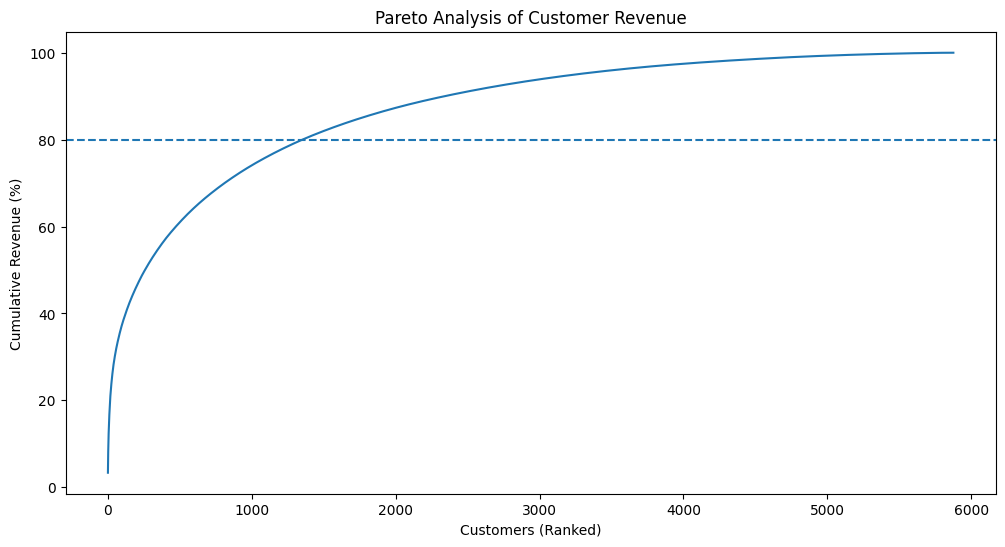

In [18]:
plt.figure(figsize=(12,6))

plt.plot(
    range(len(pareto)),
    pareto["CumulativePercent"]
)

plt.axhline(80, linestyle="--")

plt.title("Pareto Analysis of Customer Revenue")
plt.xlabel("Customers (Ranked)")
plt.ylabel("Cumulative Revenue (%)")

plt.show()

## Customer Analysis Summary

- Revenue is concentrated among a relatively small group of customers.
- Most customers place only a few orders, while a smaller segment purchases frequently.
- Repeat customers contribute disproportionately to overall revenue.
- A limited number of high-value customers account for a large share of sales, suggesting that customer retention strategies could significantly influence business performance.

## Product Analysis

1) Which products are sold in the highest quantities?

In [19]:
best_selling = (
    df.groupby(["StockCode", "Description"], as_index=False)["Quantity"].sum().sort_values(by="Quantity", ascending=False).head(10)
)

best_selling

,StockCode,Description,Quantity
4171,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,106139
4999,85123A,WHITE HANGING HEART T-LIGHT HOLDER,94142
3355,23843,"PAPER CRAFT , LITTLE BIRDIE",80995
4640,84879,ASSORTED COLOUR BIRD ORNAMENT,80082
2810,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033
4967,85099B,JUMBO BAG RED RETROSPOT,77280
121,17003,BROCADE RING PURSE,70369
1384,21977,PACK OF 60 PINK PAISLEY CAKE CASES,56061
4801,84991,60 TEATIME FAIRY CAKE CASES,54028
1607,22197,SMALL POPCORN HOLDER,48561


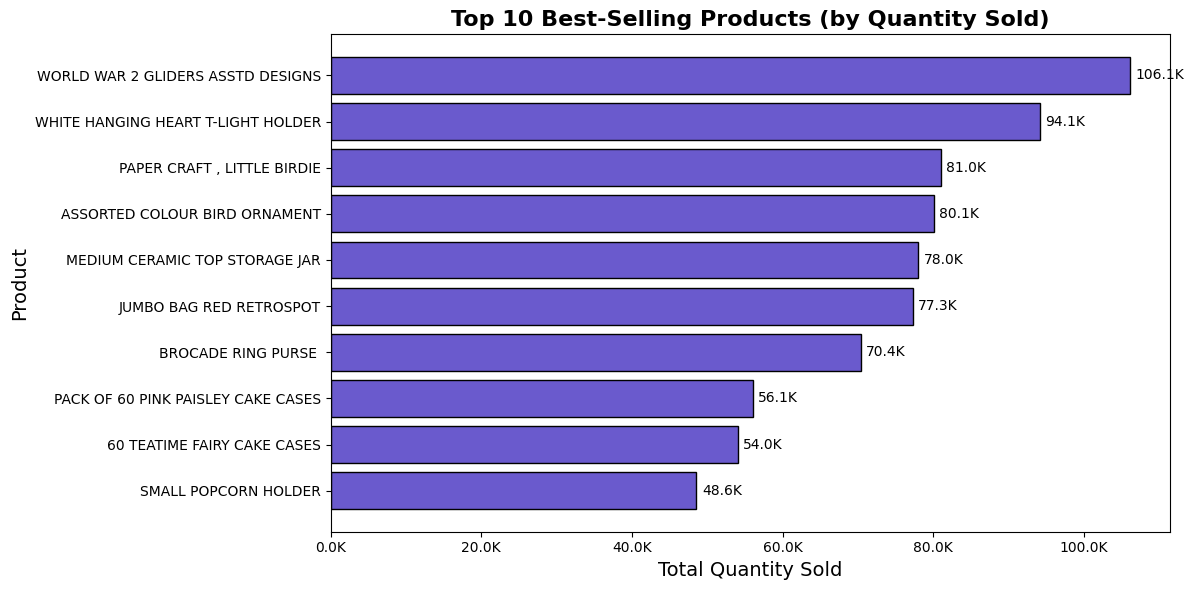

In [20]:
fig, ax = plt.subplots(figsize=(12,6))

bars = ax.barh(
    best_selling["Description"],
    best_selling["Quantity"],
    color="#6A5ACD",
    edgecolor="black"
)

ax.set_title(
    "Top 10 Best-Selling Products (by Quantity Sold)",
    fontsize=16,
    weight="bold"
)

ax.set_xlabel("Total Quantity Sold", fontsize=14)
ax.set_ylabel("Product", fontsize=14)

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x/1e3:.1f}K')
)

labels = [f'{value/1e3:.1f}K' for value in best_selling["Quantity"]]

ax.bar_label(
    bars,
    labels=labels, padding=4, fontsize=10
)

ax.invert_yaxis()

plt.tight_layout()
plt.show()

A small number of products account for a significant share of total units sold. These products represent consistently high customer demand and should be prioritized for inventory management and stock availability.

2) Which products generate the highest revenue?

In [21]:
top_revenue_products = (
    df.groupby(["StockCode", "Description"], as_index=False)["TotalAmount"].sum().sort_values(by="TotalAmount", ascending=False).head(10)
)

top_revenue_products

,StockCode,Description,TotalAmount
5615,M,Manual,339226.24
1891,22423,REGENCY CAKESTAND 3 TIER,330590.32
5614,DOT,DOTCOM POSTAGE,309854.11
4999,85123A,WHITE HANGING HEART T-LIGHT HOLDER,257546.20
3355,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60
3716,47566,PARTY BUNTING,148318.28
4967,85099B,JUMBO BAG RED RETROSPOT,145961.83
4640,84879,ASSORTED COLOUR BIRD ORNAMENT,129324.49
5617,POST,POSTAGE,125682.42
1477,22086,PAPER CHAIN KIT 50'S CHRISTMAS,117760.29


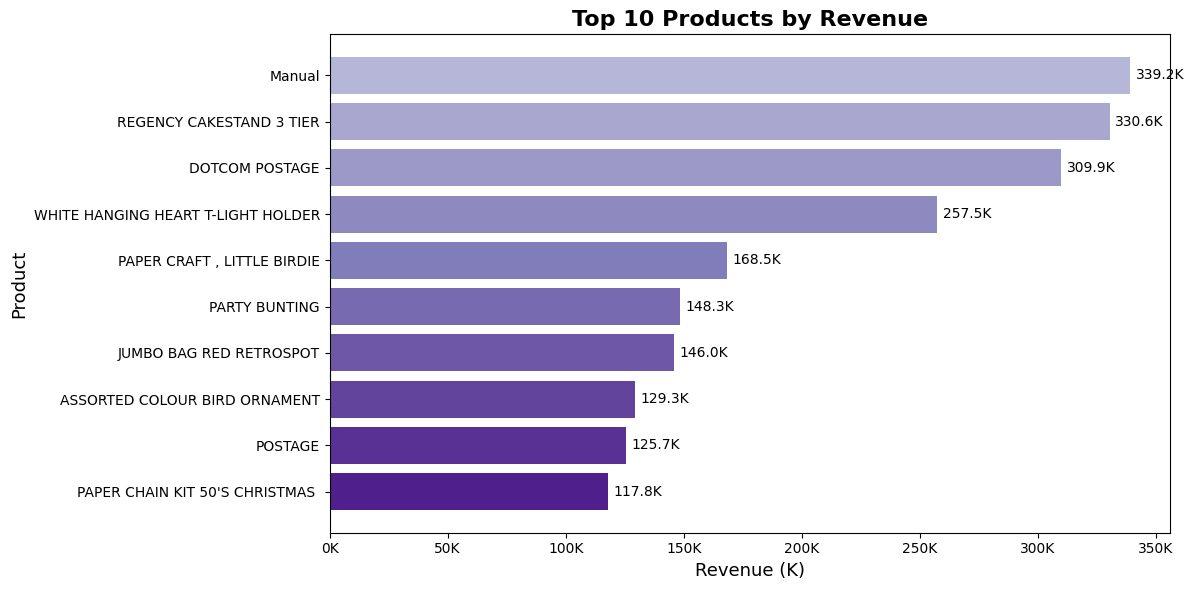

In [22]:
colors = plt.cm.Purples(
    np.linspace(0.4, 0.9, len(top_revenue_products))
)

fig, ax = plt.subplots(figsize=(12,6))

bars = ax.barh(
    top_revenue_products["Description"],
    top_revenue_products["TotalAmount"],
    color=colors,
)

ax.set_title("Top 10 Products by Revenue", fontsize=16, weight="bold")
ax.set_xlabel("Revenue (K)", fontsize=13)
ax.set_ylabel("Product", fontsize=13)

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x/1000:.0f}K')
)
labels = [f'{value/1000:.1f}K' for value in top_revenue_products["TotalAmount"]]

ax.bar_label(
    bars,
    labels=labels,
    padding=4,
    fontsize=10,
)

ax.invert_yaxis()
plt.tight_layout()
plt.show()

High-revenue products are not always the highest-volume products. These items contribute disproportionately to total sales value and should be monitored closely for pricing, demand, and profitability.

3) Revenue vs Quantity Comparison

In [23]:
product_summary = (
    df.groupby(["StockCode", "Description"], as_index=False)
      .agg(
          TotalQuantity=("Quantity", "sum"),
          TotalRevenue=("TotalAmount", "sum")
      )
)

product_summary.head()

,StockCode,Description,TotalQuantity,TotalRevenue
0,10002,INFLATABLE POLITICAL GLOBE,8671,6942.26
1,10002R,ROBOT PENCIL SHARPNER,4,20.57
2,10080,GROOVY CACTUS INFLATABLE,315,129.29
3,10109,BENDY COLOUR PENCILS,4,1.68
4,10120,DOGGY RUBBER,664,142.74


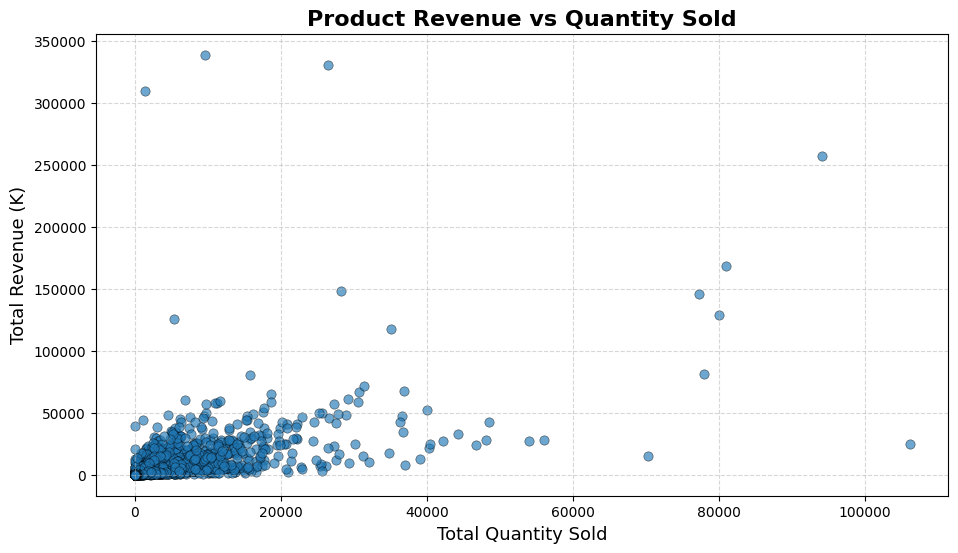

In [24]:
plt.figure(figsize=(11,6))

plt.scatter(
    product_summary["TotalQuantity"],
    product_summary["TotalRevenue"],
    s=45,
    color="#1f77b4",
    edgecolor="black",
    linewidth=0.4,
    alpha=0.65
)

plt.title("Product Revenue vs Quantity Sold",
          fontsize=16,
          weight="bold")

plt.xlabel("Total Quantity Sold", fontsize=13)
plt.ylabel("Total Revenue (K)", fontsize=13)

plt.grid(alpha=0.5, linestyle="--")

plt.show()

- Top-right: Best-performing products.
- Bottom-right: High-volume but low-value products.
- Top-left: Premium products with fewer sales.
- Bottom-left: Low-performing products

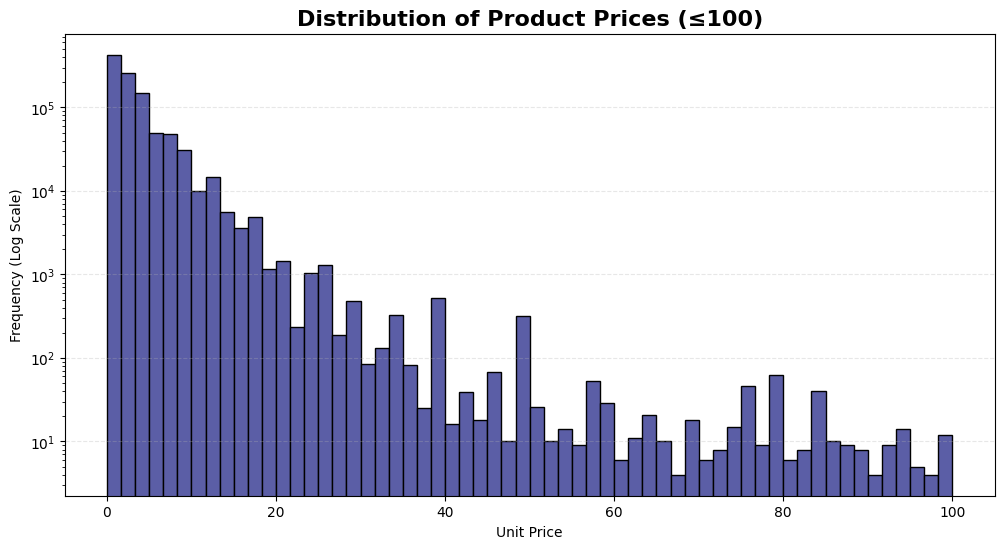

In [25]:
plt.figure(figsize=(12,6))

plt.hist(
    df[df["Price"] <= 100]["Price"],
    bins=60,
    color="#5B5EA6",
    edgecolor="black"
)

plt.yscale("log")

plt.title("Distribution of Product Prices (≤100)",
          fontsize=16,
          weight='bold')

plt.xlabel("Unit Price")
plt.ylabel("Frequency (Log Scale)")

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

Most products are concentrated in the lower price range, while only a small number of products are sold at premium prices. This indicates that the retailer primarily focuses on affordable consumer goods.

How many products sell only a few times?

In [26]:
product_orders = (
    df.groupby(["StockCode", "Description"])["Invoice"]
      .nunique()
      .sort_values()
)

product_orders.describe()

count   5630.00
mean     177.01
std      293.82
min        1.00
25%       17.00
50%       70.00
75%      211.00
max     5356.00
Name: Invoice, dtype: float64

In [27]:
sold_once = (product_orders == 1).sum()

print(f"Products sold only once: {sold_once}")

Products sold only once: 248


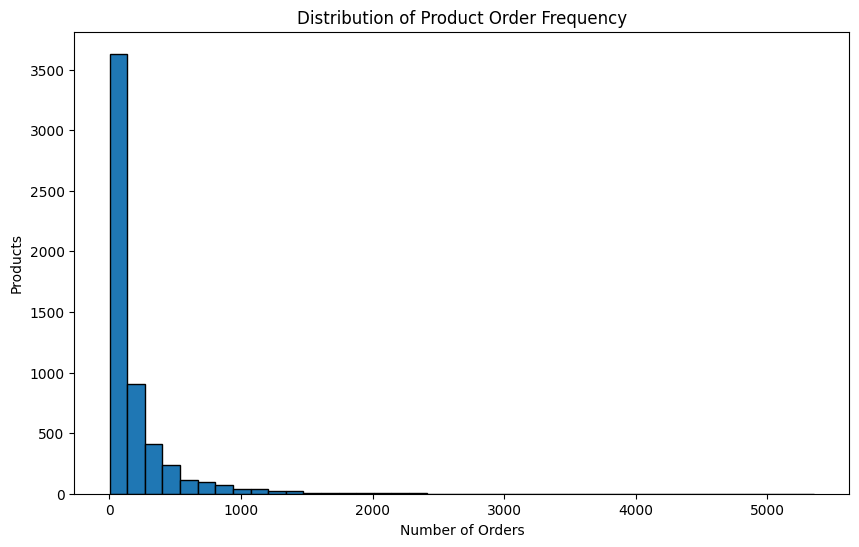

In [28]:
plt.figure(figsize=(10,6))

plt.hist(product_orders, bins=40,edgecolor = 'black')

plt.title("Distribution of Product Order Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Products")


plt.show()

The analysis reveals that a small group of products drives most sales activity, while a large proportion of products experience comparatively low purchase frequency.

In [29]:
product_sales = (
    df.groupby(["StockCode", "Description"])["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
)

top10_revenue = product_sales.head(10).sum()

total_revenue = product_sales.sum()

print(f"Top 10 Revenue Contribution: {(top10_revenue / total_revenue) * 100:.2f}%")

Top 10 Revenue Contribution: 10.12%


### Pareto Analysis 
Do 20% of products generate around 80% of the revenue?

In [30]:
pareto_products = (
    df.groupby(["StockCode", "Description"])["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

pareto_products["CumulativeRevenue"] = pareto_products["TotalAmount"].cumsum()

pareto_products["CumulativePercentage"] = (
    pareto_products["CumulativeRevenue"]
    / pareto_products["TotalAmount"].sum()
) * 100

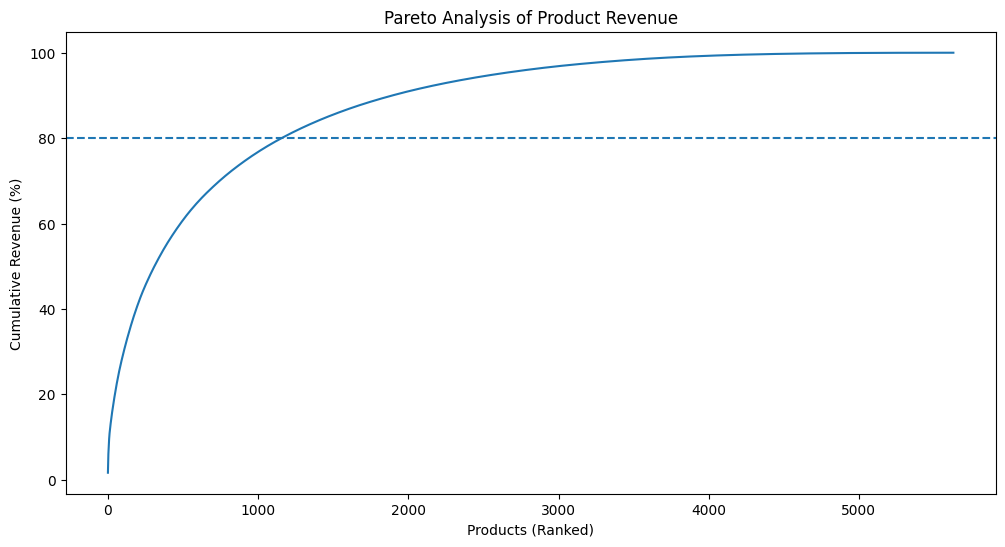

In [31]:
plt.figure(figsize=(12,6))

plt.plot(
    range(len(pareto_products)),
    pareto_products["CumulativePercentage"]
)

plt.axhline(80, linestyle="--")

plt.title("Pareto Analysis of Product Revenue")
plt.xlabel("Products (Ranked)")
plt.ylabel("Cumulative Revenue (%)")

plt.show()

The curve reaches 80% quickly, it indicates that a relatively small number of products generate most of the revenue. These products should receive priority in inventory planning, promotions, and demand forecasting.

## Product Analysis Summary

- A limited number of products dominate sales volume.
- Revenue is concentrated among a relatively small set of products.
- Most products fall within a lower price range.
- The product catalog exhibits a long-tail distribution, with many products purchased infrequently.
- Pareto analysis indicates whether a small subset of products contributes disproportionately to total revenue, supporting targeted inventory and marketing strategies.

## Country Analysis


1) Which countries contribute the highest revenue?

In [32]:
country_revenue = (
    df.groupby("Country", as_index=False)["TotalAmount"].sum().sort_values(by="TotalAmount", ascending=False).head(10)
)

country_revenue

,Country,TotalAmount
40,United Kingdom,17410196.12
11,EIRE,658767.31
26,Netherlands,554038.09
15,Germany,425019.71
14,France,350456.09
0,Australia,169283.46
34,Spain,108332.49
36,Switzerland,100685.59
35,Sweden,91869.82
10,Denmark,68580.69


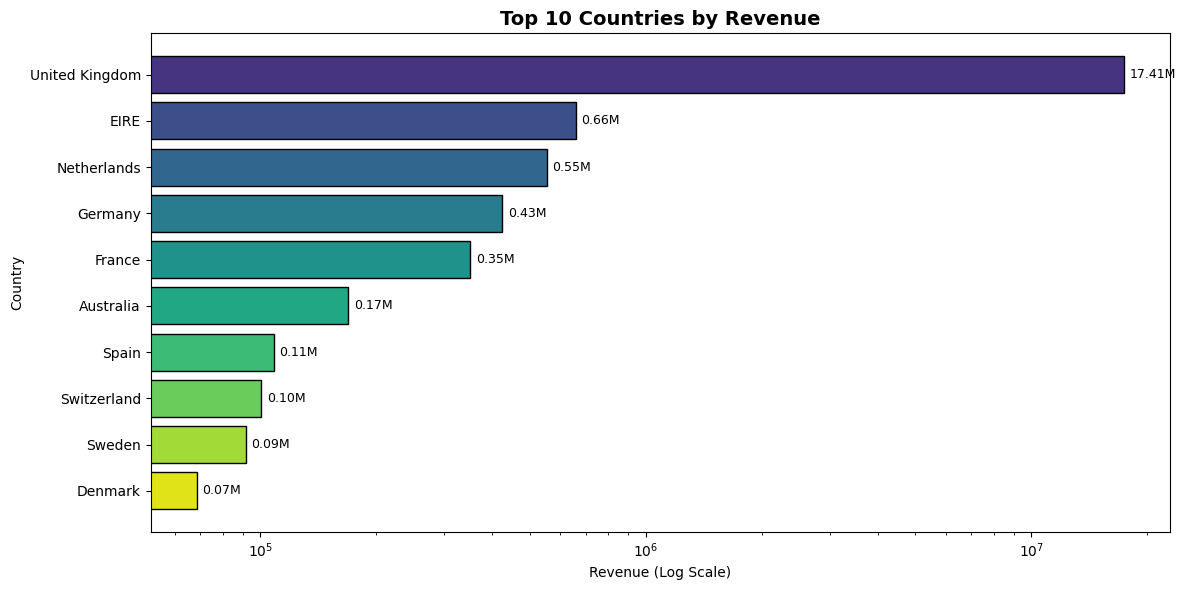

In [42]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(12,6))
colors = plt.cm.viridis(np.linspace(0.15, 0.95, len(country_revenue)))
ax = plt.gca()

plt.barh(
    country_revenue["Country"],
    country_revenue["TotalAmount"],
    color = colors ,
    edgecolor='black'
)

plt.xscale('log')

plt.title("Top 10 Countries by Revenue", fontsize=14, weight='bold')
plt.xlabel("Revenue (Log Scale)")
plt.ylabel("Country")

# Bar labels
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{x/1e6:.2f}M' for x in country_revenue["TotalAmount"]],
        padding=4,
        fontsize=9
    )

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

Revenue is concentrated in a small number of countries and UK holds it in majority with respect to others. These markets represent the retailer's strongest revenue sources and should receive priority in marketing, inventory planning, and customer retention initiatives.

2) Which countries place the most orders?

In [43]:
country_orders = (
    df.groupby("Country", as_index=False)["Invoice"].nunique().sort_values(by="Invoice", ascending=False).head(10)
)

country_orders

,Country,Invoice
40,United Kingdom,36536
15,Germany,789
11,EIRE,626
14,France,623
26,Netherlands,228
34,Spain,154
3,Belgium,149
35,Sweden,105
30,Portugal,95
0,Australia,95


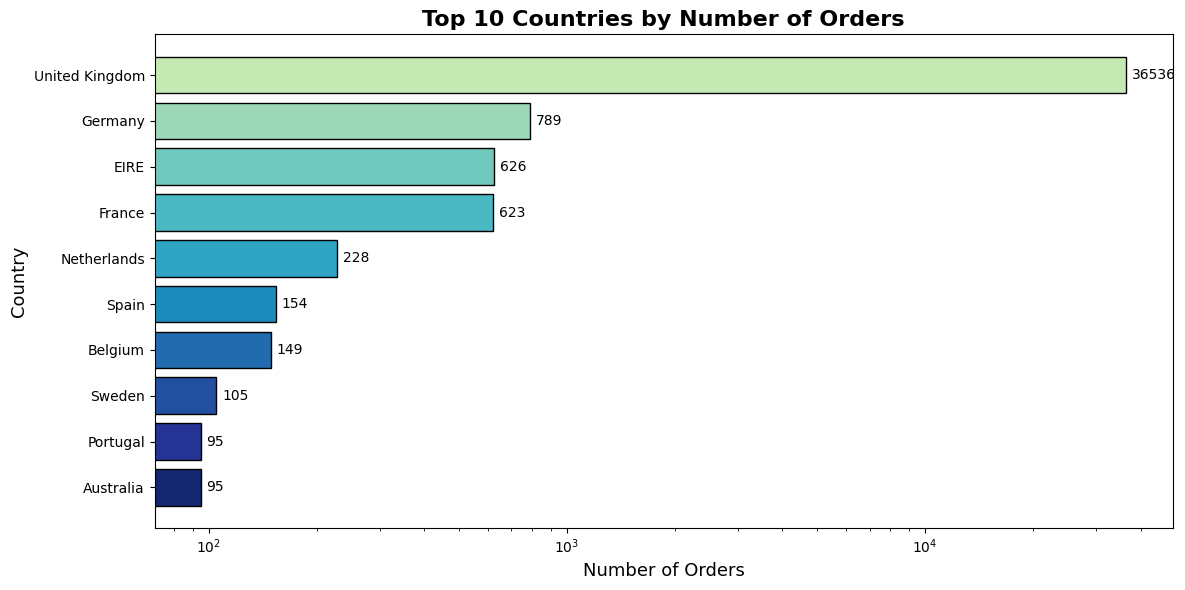

In [52]:
import numpy as np
colors = plt.cm.YlGnBu(np.linspace(0.25, 0.95, len(country_revenue)))

plt.figure(figsize=(12,6))

ax = plt.gca()

plt.barh(
    country_orders["Country"],
    country_orders["Invoice"],
    color=colors,
    edgecolor="black"
)

plt.xscale('log')
plt.title("Top 10 Countries by Number of Orders",
          fontsize=16,
          weight="bold")

plt.xlabel("Number of Orders", fontsize=13)
plt.ylabel("Country", fontsize=13)

# Bar Labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=4,
        fontsize=10,
    )

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

A country with many orders isn't necessarily the one generating the highest revenue but UK stands here at the top too. This distinction helps identify high-volume versus high-value markets.

3) Which countries have the largest customer base?

In [53]:
country_customers = (
    df.groupby("Country", as_index=False)["Customer ID"].nunique().sort_values(by="Customer ID", ascending=False).head(10)
)

country_customers

,Country,Customer ID
40,United Kingdom,5350
15,Germany,107
14,France,95
34,Spain,41
3,Belgium,29
30,Portugal,24
36,Switzerland,22
26,Netherlands,22
35,Sweden,19
20,Italy,17


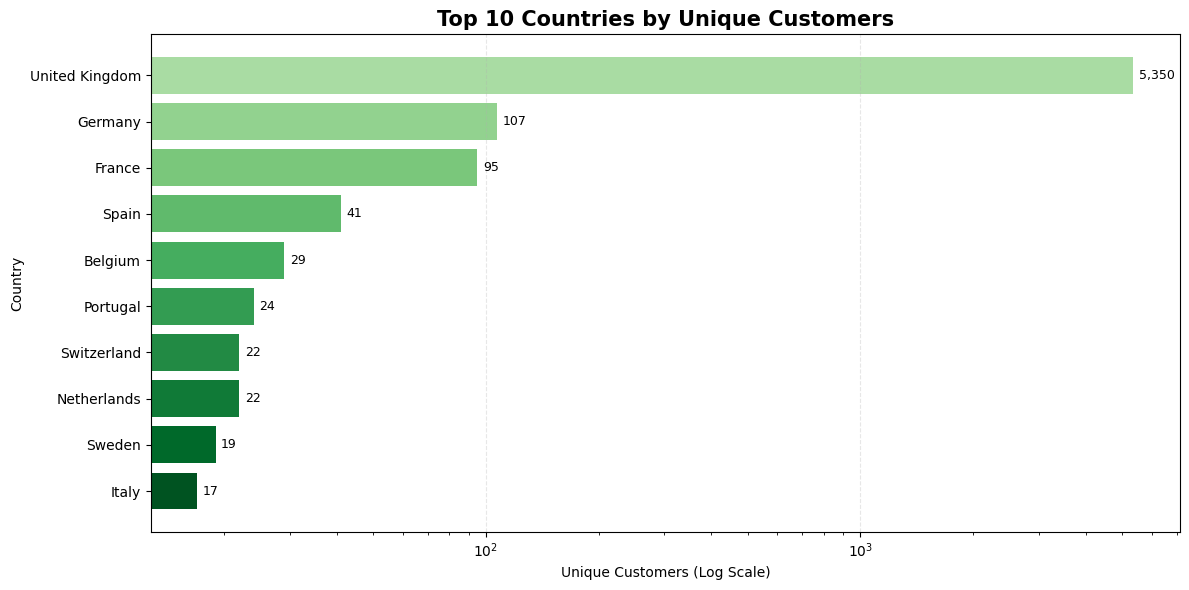

In [62]:
plt.figure(figsize=(12,6))

colors = plt.cm.Greens(np.linspace(0.35, 0.95, len(country_customers)))

ax = plt.gca()

plt.barh(
    country_customers["Country"],
    country_customers["Customer ID"],
    color=colors
)

plt.xscale('log')

plt.title("Top 10 Countries by Unique Customers", fontsize=15, weight='bold')
plt.xlabel("Unique Customers (Log Scale)")
plt.ylabel("Country")

# Bar Labels
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{int(x):,}' for x in country_customers["Customer ID"]],
        padding=4,
        fontsize=9,
    )

plt.gca().invert_yaxis()

plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

This identifies where the customer base is strongest, helping evaluate market penetration.

In [63]:
country_quantity = (
    df.groupby("Country", as_index=False)["Quantity"]
      .sum()
      .sort_values(by="Quantity", ascending=False)
      .head(10)
)

country_quantity

,Country,Quantity
40,United Kingdom,9187753
26,Netherlands,383879
11,EIRE,336329
14,France,271901
10,Denmark,237471
15,Germany,225154
0,Australia,103759
35,Sweden,88633
36,Switzerland,52762
34,Spain,50307


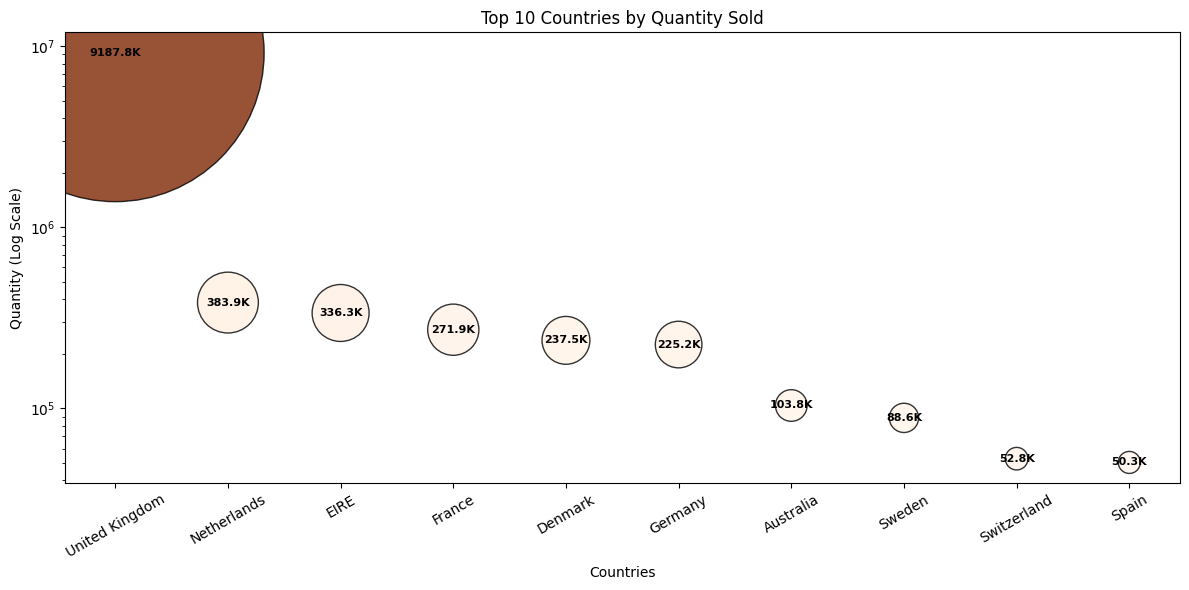

In [70]:
plt.figure(figsize=(12,6))

sizes = country_quantity["Quantity"]/200

plt.scatter(
    country_quantity["Country"],
    country_quantity["Quantity"],
    s=sizes,
    c=country_quantity["Quantity"],
    cmap="Oranges",
    alpha=0.8,
    edgecolors="black"
)

for i, value in enumerate(country_quantity["Quantity"]):
    plt.text(
        country_quantity["Country"].iloc[i],
        value,
        f"{value/1000:.1f}K",
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold",
        color="black"
    )
    
plt.yscale("log")

plt.xticks(rotation=30)

plt.title("Top 10 Countries by Quantity Sold")
plt.ylabel("Quantity (Log Scale)")
plt.xlabel("Countries")

plt.tight_layout()
plt.show()

High product volume does not always translate to high revenue and Netherlands came up here as a brilliant example. Comparing this chart with revenue helps identify markets purchasing lower-priced versus higher-priced products.

4) Which countries generate the highest revenue per customer?

In [72]:
country_summary = (
    df.groupby("Country")
      .agg(
          Revenue=("TotalAmount", "sum"),
          Customers=("Customer ID", "nunique")
      )
      .reset_index()
)

country_summary["RevenuePerCustomer"] = (
    country_summary["Revenue"] /
    country_summary["Customers"]
)

country_summary = country_summary.sort_values(
    by="RevenuePerCustomer",
    ascending=False
).head(10)

country_summary

,Country,Revenue,Customers,RevenuePerCustomer
4,Bermuda,1253.14,0,inf
17,Hong Kong,23685.52,0,inf
11,EIRE,658767.31,5,131753.46
33,Singapore,25317.06,1,25317.06
26,Netherlands,554038.09,22,25183.55
0,Australia,169283.46,15,11285.56
10,Denmark,68580.69,12,5715.06
18,Iceland,4921.53,1,4921.53
24,Lithuania,4892.68,1,4892.68
35,Sweden,91869.82,19,4835.25


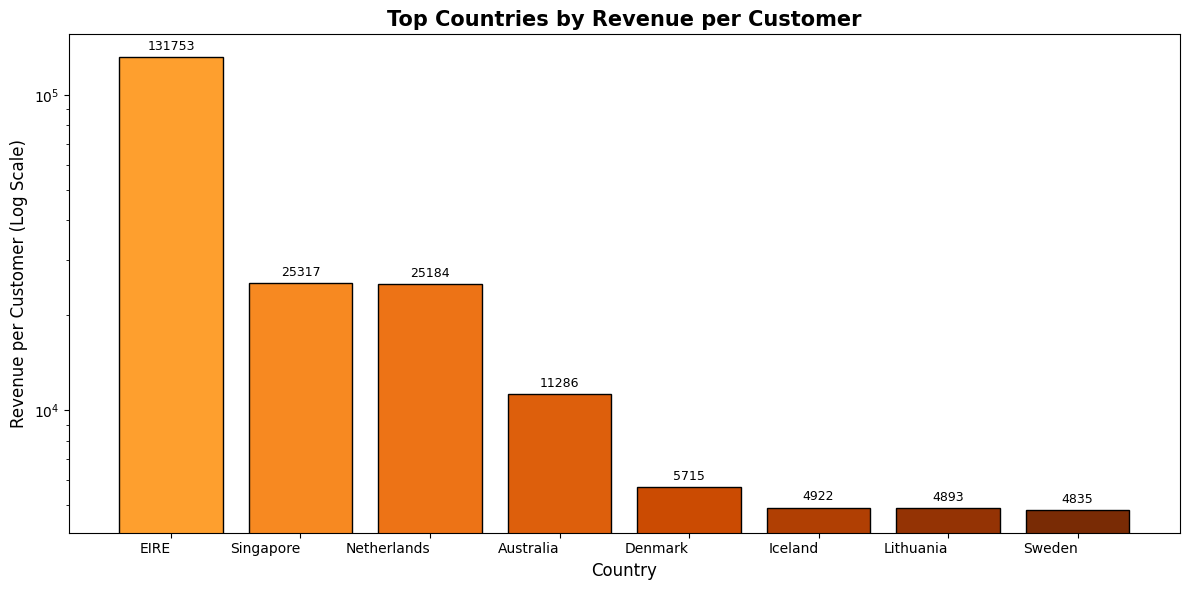

In [80]:
import numpy as np

plt.figure(figsize=(12,6))

colors = plt.cm.YlOrBr(np.linspace(0.35, 0.95, len(country_summary)))

ax = plt.gca()

bars = plt.bar(
    country_summary["Country"],
    country_summary["RevenuePerCustomer"],
    color=colors,
    edgecolor="black"
)

plt.yscale("log")

plt.title("Top Countries by Revenue per Customer",
          fontsize=15,
          weight="bold")

plt.xlabel("Country", fontsize=12)
plt.ylabel("Revenue per Customer (Log Scale)", fontsize=12)

plt.xticks(rotation=0, ha="right")

# Bar Labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3,
        fontsize=9,
    )

plt.tight_layout()
plt.show()

This metric combines market size and customer value. Countries with high revenue per customer may justify premium marketing strategies or personalized loyalty programs.

## Country Analysis Summary

- Revenue is concentrated in a limited number of countries.
- Some countries generate high revenue through large order volumes, while others achieve high revenue through higher-value purchases.
- Average Order Value varies significantly across markets, indicating differences in customer purchasing behavior.
- Revenue per customer highlights the most valuable geographic markets and can guide expansion, marketing, and inventory decisions.

# Time-Based Analysis

1) How does revenue change month by month?

In [83]:
monthly_revenue = (
    df.groupby("Month", as_index=False)["TotalAmount"].sum()
)

monthly_revenue

,Month,TotalAmount
0,1,1340966.72
1,2,1074050.29
2,3,1547130.52
3,4,1215843.74
4,5,1427002.11
5,6,1510084.32
6,7,1366886.39
7,8,1453093.29
8,9,1978132.18
9,10,2313165.95


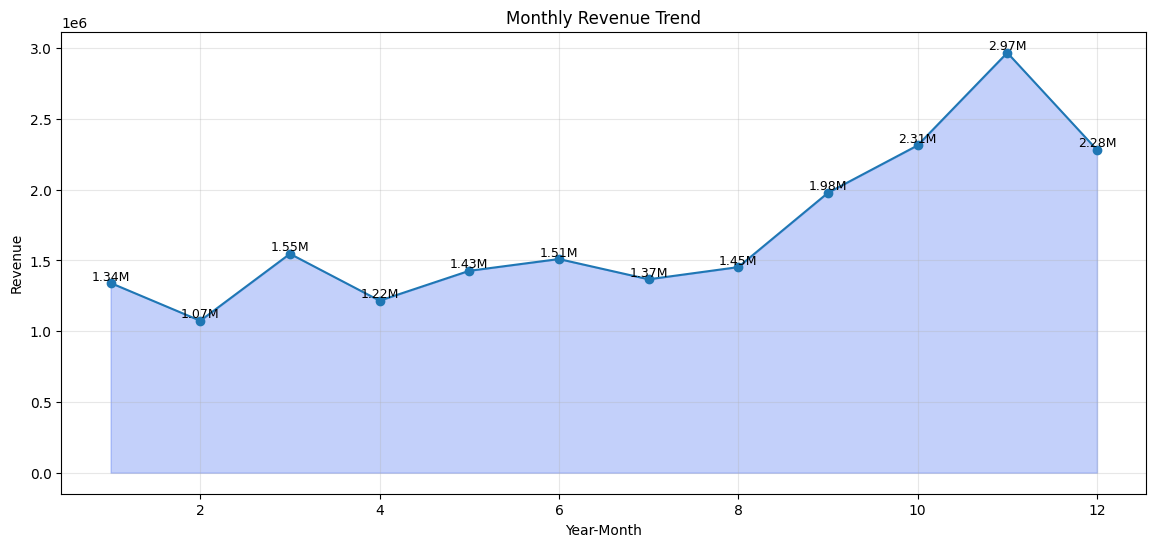

In [105]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_revenue["Month"],
    monthly_revenue["TotalAmount"],
    marker="o"
)

plt.fill_between(
    monthly_revenue["Month"],
    monthly_revenue["TotalAmount"],
    alpha=0.25,
    color="#1346ED"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Year-Month")
plt.ylabel("Revenue")

for x, y in zip(monthly_revenue["Month"], monthly_revenue["TotalAmount"]):
    plt.text(
        x,
        y,
        f'{y/1e6:.2f}M',
        ha='center',
        va='bottom',
        fontsize=9,
    
    )
    
plt.xticks(rotation=0)

plt.grid(alpha=0.3)

plt.show()

2) Are more orders being placed over time?

In [92]:
monthly_orders = (
    df.groupby("Month")["Invoice"]
      .nunique()
      .reset_index(name="Orders")
)
monthly_orders

,Month,Orders
0,1,2191
1,2,2301
2,3,3135
3,4,2708
4,5,3181
5,6,3178
6,7,3005
7,8,2787
8,9,3676
9,10,4341


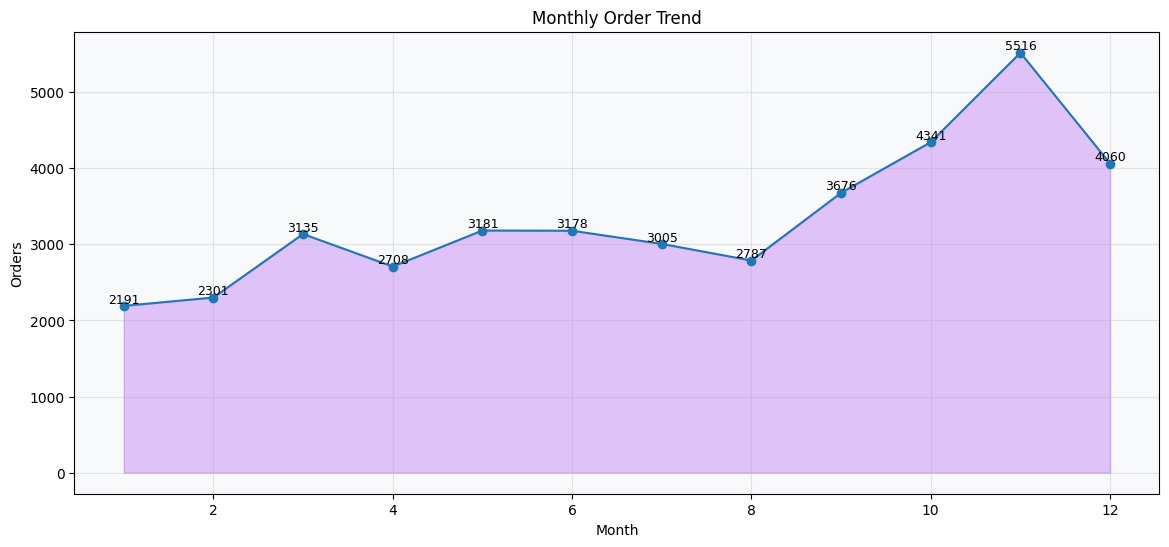

In [107]:
plt.figure(figsize=(14,6))
plt.gca().set_facecolor("#F8F9FA")

plt.plot(
    monthly_orders["Month"],
    monthly_orders["Orders"],
    marker="o"
)
plt.fill_between(
    monthly_orders["Month"],
    monthly_orders["Orders"],
    alpha=0.25,
    color="#931EF3"
)


for x, y in zip(monthly_orders["Month"], monthly_orders["Orders"]):
    plt.text(
        x,
        y,
        f"{y:}", 
        ha='center',
        va='bottom',
        fontsize=9,
    
    )
    
plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Orders")

plt.xticks(rotation=0)

plt.grid(alpha=0.3)

plt.show()

3) Which quarter performs best?

In [108]:
quarter_revenue = (
    df.groupby("Quarter", as_index=False)["TotalAmount"]
      .sum()
)
quarter_revenue

,Quarter,TotalAmount
0,1,3962147.53
1,2,4152930.17
2,3,4798111.86
3,4,7563070.88


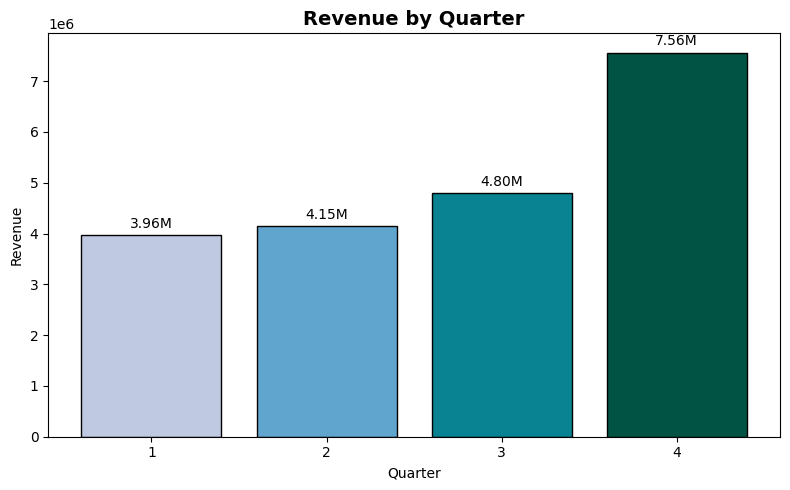

In [113]:
plt.figure(figsize=(8,5))

colors = plt.cm.PuBuGn(np.linspace(0.30, 0.95, len(quarter_revenue)))

ax = plt.gca()

bars = ax.bar(
    quarter_revenue["Quarter"].astype(str),
    quarter_revenue["TotalAmount"],
    color=colors,
    edgecolor="black"
)

# Add value labels
labels = [f"{x/1e6:.2f}M" for x in quarter_revenue["TotalAmount"]]

ax.bar_label(
    bars,
    labels=labels,
    padding=3,
    fontsize=10,
  
)

plt.title("Revenue by Quarter", fontsize=14, weight="bold")
plt.xlabel("Quarter")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

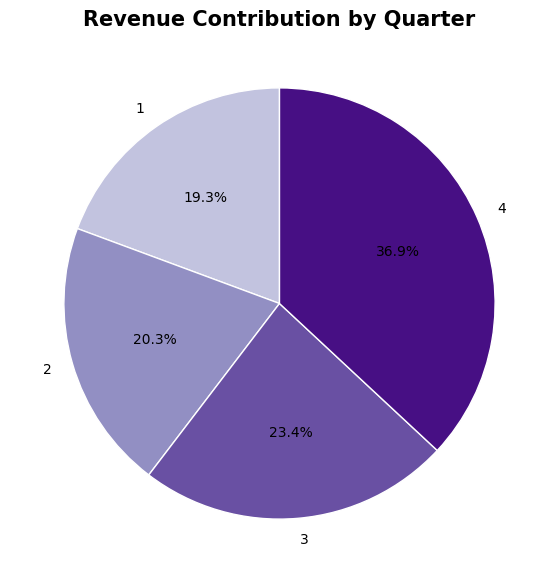

In [116]:
plt.figure(figsize=(7,7))

colors = plt.cm.Purples(np.linspace(0.35, 0.95, len(quarter_revenue)))

plt.pie(
    quarter_revenue["TotalAmount"],
    labels=quarter_revenue["Quarter"],
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops=dict(edgecolor="white")
)

plt.title("Revenue Contribution by Quarter", fontsize=15, weight="bold")

plt.show()

This helps management understand seasonal business performance.

4) Which months generate the highest revenue?

In [118]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_sales = (
    df.groupby("MonthName", as_index=False)["TotalAmount"]
      .sum()
)

monthly_sales["MonthName"] = pd.Categorical(
    monthly_sales["MonthName"],
    categories=month_order,
    ordered=True
)

monthly_sales = monthly_sales.sort_values("MonthName")
monthly_sales

,MonthName,TotalAmount
4,January,1340966.72
3,February,1074050.29
7,March,1547130.52
0,April,1215843.74
8,May,1427002.11
6,June,1510084.32
5,July,1366886.39
1,August,1453093.29
11,September,1978132.18
10,October,2313165.95


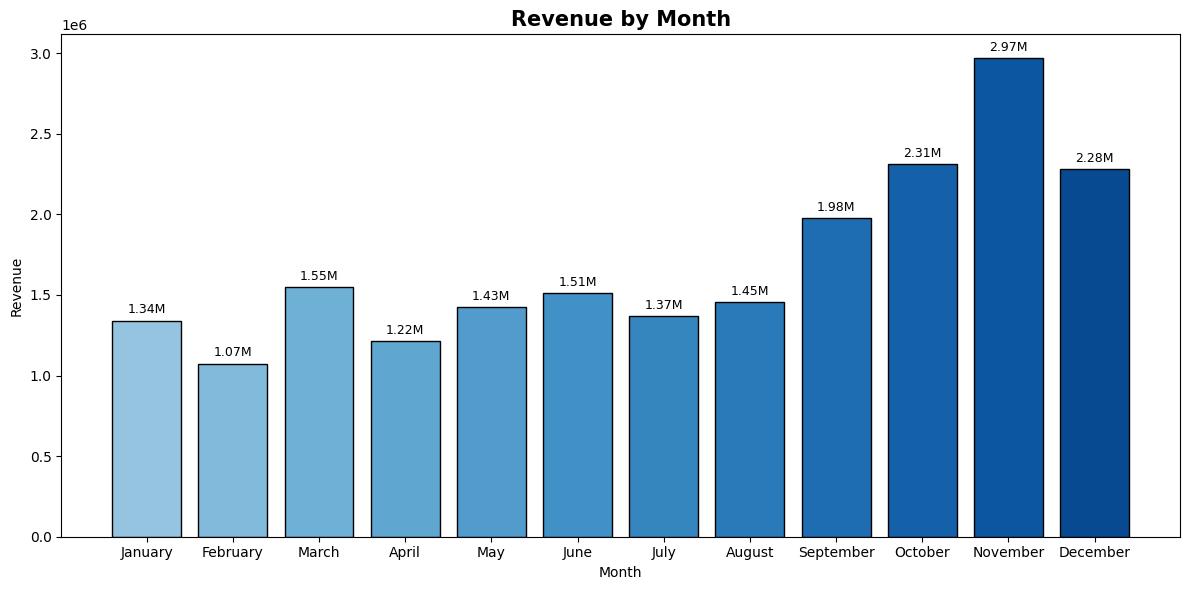

In [121]:
plt.figure(figsize=(12,6))

ax = plt.gca()

bars = ax.bar(
    monthly_sales["MonthName"],
    monthly_sales["TotalAmount"],
    color=plt.cm.Blues(np.linspace(0.4, 0.9, len(monthly_sales))),
    edgecolor="black"
)

# Bar Labels
labels = [f"{x/1e6:.2f}M" for x in monthly_sales["TotalAmount"]]

ax.bar_label(
    bars,
    labels=labels,
    padding=3,
    fontsize=9,
)

plt.xticks(rotation=0)

plt.title("Revenue by Month", fontsize=15, weight="bold")
plt.xlabel("Month")
plt.ylabel("Revenue")


plt.tight_layout()
plt.show()

This shows the monthly revenue trend so it will become easy to target the time for sales.

5) Which days of the week drive the most revenue?

In [122]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_sales = (
    df.groupby("DayName", as_index=False)["TotalAmount"]
      .sum()
)

weekday_sales["DayName"] = pd.Categorical(
    weekday_sales["DayName"],
    categories=weekday_order,
    ordered=True
)

weekday_sales = weekday_sales.sort_values("DayName")
weekday_sales

,DayName,TotalAmount
1,Monday,3581594.18
5,Tuesday,4078149.96
6,Wednesday,3488444.33
4,Thursday,4195212.76
0,Friday,3323908.88
2,Saturday,9803.05
3,Sunday,1799147.28


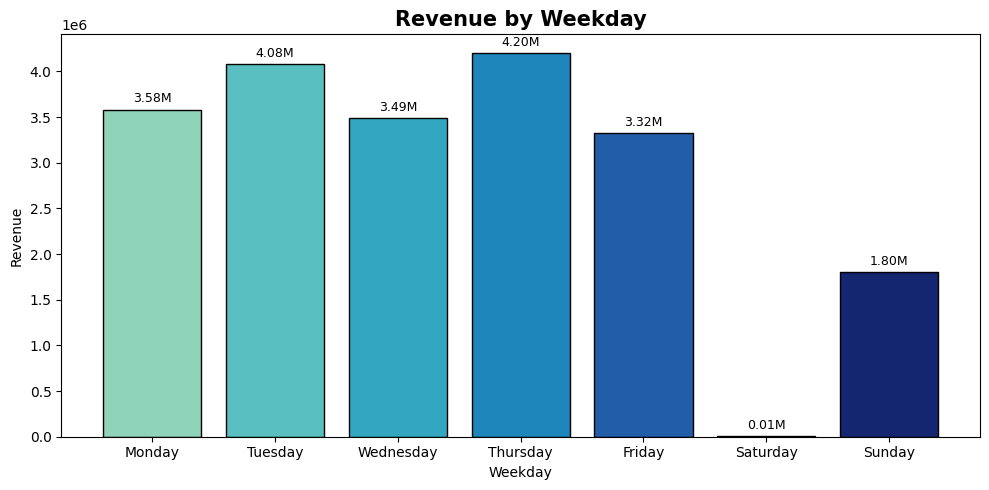

In [127]:
plt.figure(figsize=(10,5))

ax = plt.gca()

bars = ax.bar(
    weekday_sales["DayName"],
    weekday_sales["TotalAmount"],
    color=plt.cm.YlGnBu(np.linspace(0.35, 0.95, len(weekday_sales))),
    edgecolor="black"
)

# Bar Labels
labels = [f"{x/1e6:.2f}M" for x in weekday_sales["TotalAmount"]]

ax.bar_label(
    bars,
    labels=labels,
    padding=3,
    fontsize=9,
)

plt.title("Revenue by Weekday", fontsize=15, weight="bold")
plt.xlabel("Weekday")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

- Increase staffing on busy days.
- Schedule promotions on slower days.

6) At what time do customers purchase the most?

In [128]:
hourly_sales = (
    df.groupby("Hour", as_index=False)["TotalAmount"]
      .sum()
)
hourly_sales

,Hour,TotalAmount
0,6,4.25
1,7,75765.57
2,8,528185.57
3,9,1769631.03
4,10,2581131.33
5,11,2535325.46
6,12,2850377.67
7,13,2548467.54
8,14,2321684.73
9,15,2394943.79


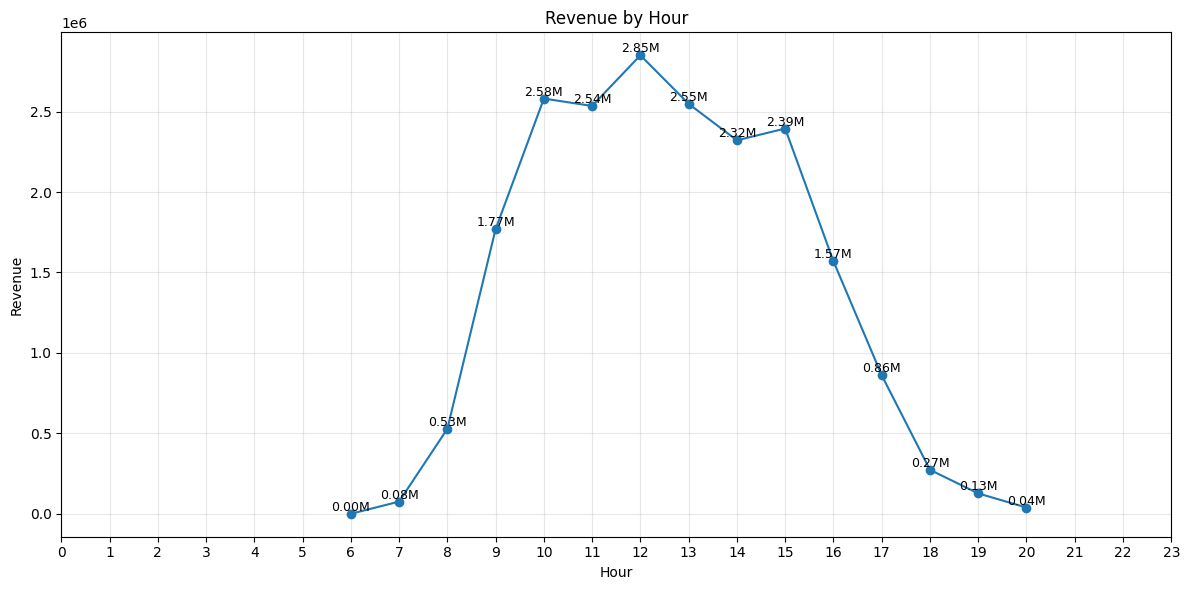

In [138]:
plt.figure(figsize=(12,6))

plt.plot(
    hourly_sales["Hour"],
    hourly_sales["TotalAmount"],
    marker="o"
)

plt.xticks(range(0,24))

for x, y in zip(hourly_sales["Hour"], hourly_sales["TotalAmount"]):
    plt.text(
        x,
        y,
        f"{y/1e6:.2f}M", 
        ha='center',
        va='bottom',
        fontsize=9,
    
    )

plt.title("Revenue by Hour")
plt.xlabel("Hour")
plt.ylabel("Revenue")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

- Identify peak shopping hours.
- Time flash sales and email campaigns.
- Optimize staffing.

7) Weekend vs Weekday

In [142]:
daytype_sales = (
    df.groupby("IsWeekend", as_index=False)["TotalAmount"]
      .sum()
)

daytype_sales

,IsWeekend,TotalAmount
0,False,18667310.12
1,True,1808950.33


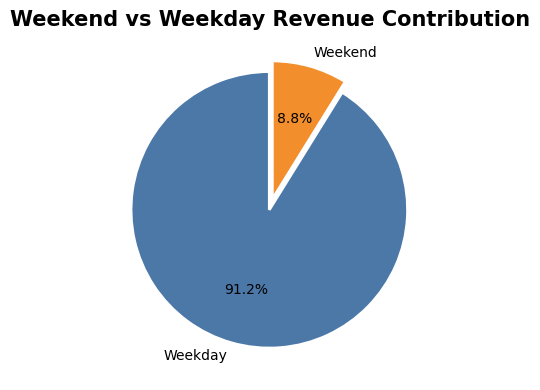

In [146]:
plt.figure(figsize=(4,4))

colors = ["#4C78A8", "#F28E2B"]

plt.pie(
    daytype_sales["TotalAmount"],
    labels=["Weekday", "Weekend"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4C78A8", "#F28E2B"],
    explode=[0.02, 0.06],
    wedgeprops=dict(edgecolor="white", linewidth=2)
)

plt.title(
    "Weekend vs Weekday Revenue Contribution",
    fontsize=15,
    weight="bold"
)

plt.tight_layout()
plt.show()

#### Weekdays contribute a huge part of about 91% in the whole sales revenue.

## Time-Based Analysis Summary

- Monthly revenue trends reveal periods of business growth and seasonal demand.
- Revenue varies across quarters and months, indicating opportunities for seasonal inventory planning.
- Weekday analysis highlights the strongest and weakest sales days, supporting staffing and promotional decisions.
- Hourly sales patterns identify peak purchasing hours that can guide marketing campaigns and operational planning.
- Comparing weekday and weekend revenue helps evaluate differences in customer shopping behavior.

## Invoice Analysis

1) How many products are typically purchased in one order?

In [156]:
basket_distribution = (
    df.groupby("Invoice")["Quantity"]
      .count()
)

basket_distribution

Invoice
489434      8
489435      4
489436     19
489437     23
489438     17
           ..
564438     23
564439     11
564440      8
564471     10
A563185     1
Name: Quantity, Length: 40079, dtype: int64

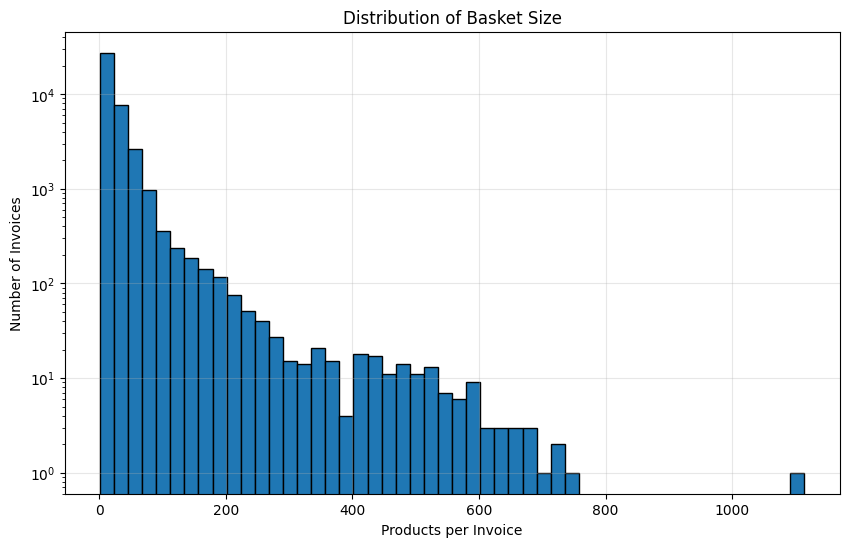

In [155]:
plt.figure(figsize=(10,6))

plt.hist(basket_distribution, bins=50,edgecolor = 'black')

plt.title("Distribution of Basket Size")
plt.xlabel("Products per Invoice")
plt.ylabel("Number of Invoices")
plt.yscale('log')

plt.grid(alpha=0.3)

plt.show()

- Small basket sizes indicate quick purchases.
- Large baskets may represent wholesale or bulk purchases.

2) How much do customers spend per order?

In [164]:
invoice_value = (
    df.groupby("Invoice")["TotalAmount"]
      .sum()
)
invoice_value

Invoice
489434      505.30
489435      145.80
489436      630.33
489437      310.75
489438     2286.24
            ...   
564438      496.30
564439      115.34
564440      121.25
564471      225.10
A563185   11062.06
Name: TotalAmount, Length: 40079, dtype: float64

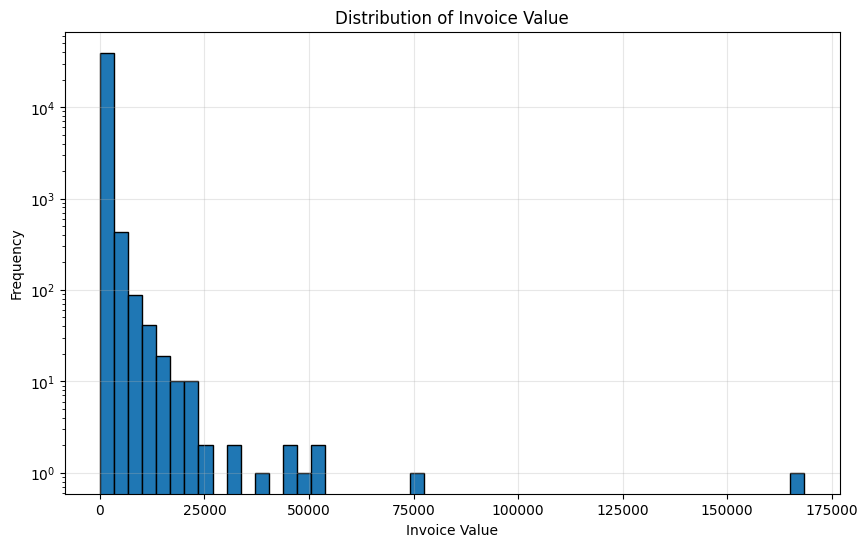

In [162]:
plt.figure(figsize=(10,6))

plt.hist(invoice_value, bins=50,edgecolor ='black')

plt.title("Distribution of Invoice Value")
plt.xlabel("Invoice Value")
plt.ylabel("Frequency")

plt.yscale('log')

plt.grid(alpha=0.3)

plt.show()

This reveals whether the business relies on many small orders or a few high-value purchases.

## Correlation Analysis

#### Correlation Heatmap

In [165]:
numeric_cols = [
    "Quantity",
    "Price",
    "TotalAmount",
    "InvoiceTotal",
    "BasketSize",
    "PurchaseFrequency",
    "AverageOrderValue",
    "CustomerRevenue",
    "ProductPurchaseCount",
    "ProductRevenue"
]

corr = df[numeric_cols].corr()

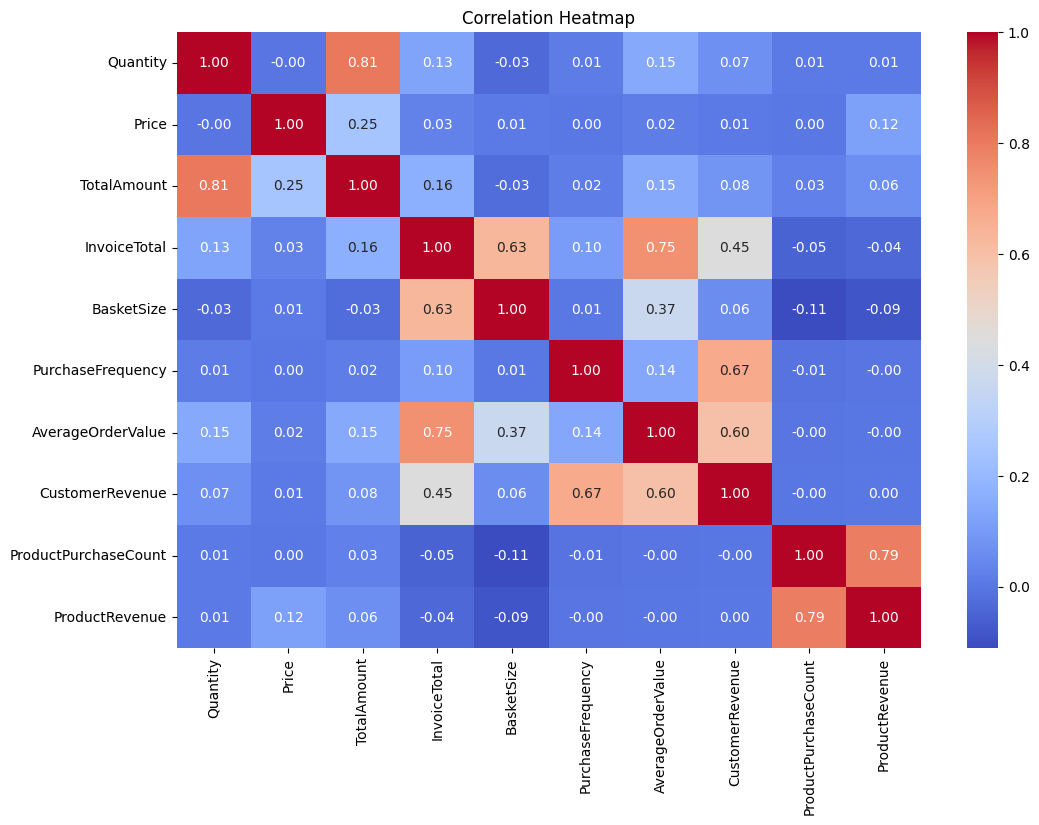

In [166]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

TotalAmount shows a strong positive relationship with InvoiceTotal and CustomerRevenue, indicating that higher-value transactions contribute significantly to overall customer value. Price and Quantity exhibit a weaker relationship, suggesting customers purchase both low- and high-priced products in varying quantities.

### Outlier Analysis

Quantity Outliers

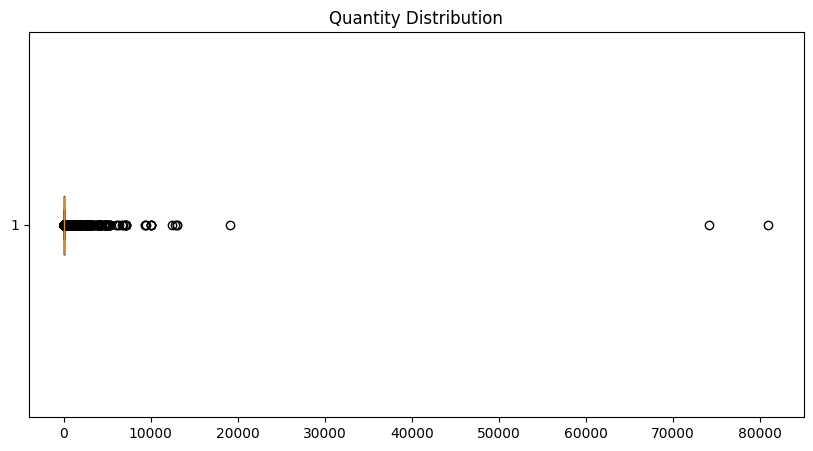

In [170]:
plt.figure(figsize=(10,5))

plt.boxplot(df["Quantity"], vert=False)

plt.title("Quantity Distribution")

plt.show()

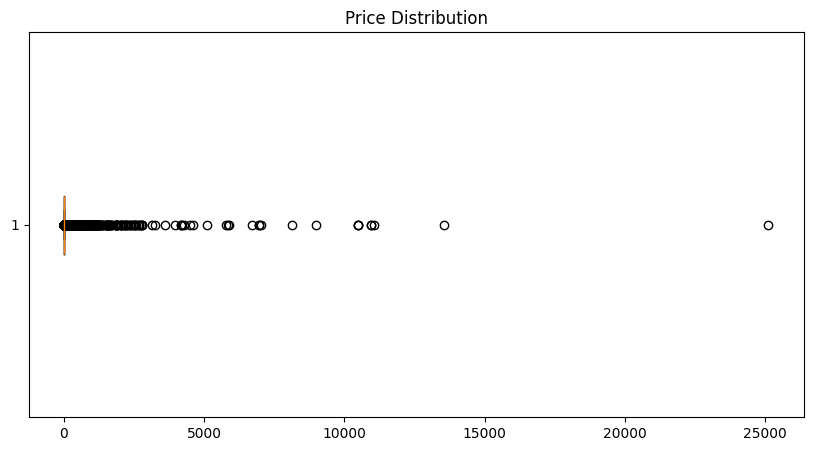

In [171]:
plt.figure(figsize=(10,5))

plt.boxplot(df["Price"], vert=False)

plt.title("Price Distribution")

plt.show()

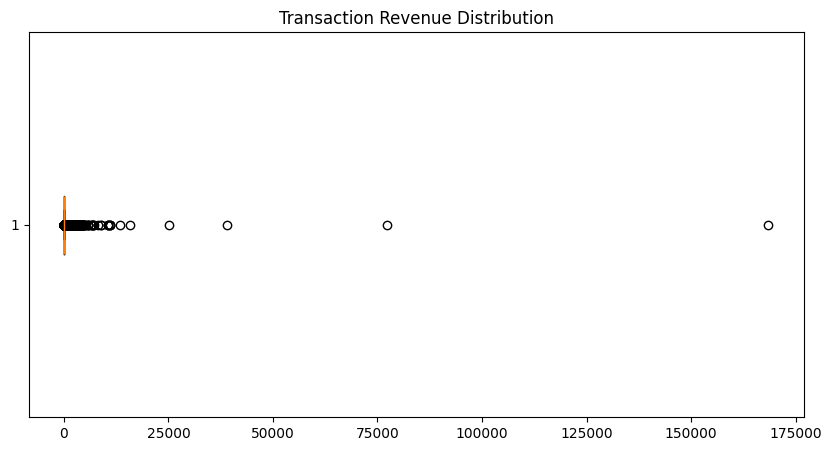

In [172]:
plt.figure(figsize=(10,5))

plt.boxplot(df["TotalAmount"], vert=False)

plt.title("Transaction Revenue Distribution")

plt.show()

High-value transactions likely represent bulk purchases or wholesale customers rather than data errors. These observations are retained because they reflect genuine business activity and are important for revenue analysis.

# Executive Business Insights

## Sales

- Revenue is concentrated in a relatively small number of high-value invoices.
- Monthly sales show seasonal fluctuations, indicating periods of increased customer demand.

## Customers

- A small percentage of customers contribute a disproportionately large share of revenue.
- Repeat customers generate significantly more value than one-time customers.

## Products

- Best-selling products differ from highest-revenue products.
- A small subset of products contributes most of the total revenue.
- The product portfolio exhibits a long-tail distribution.

## Geography

- Revenue is concentrated in a limited number of countries.
- Average Order Value varies across markets, indicating differences in purchasing behavior.

## Time

- Customer purchasing behavior changes by month, weekday, and hour.
- Peak shopping periods present opportunities for targeted promotions and staffing optimization.

## Business Recommendations

1. Focus retention efforts on high-value customers.
2. Prioritize inventory for high-demand and high-revenue products.
3. Schedule promotions during low-performing periods.
4. Optimize staffing during peak shopping hours.
5. Expand marketing investment in high-performing geographic markets.